# Function 7 Analysis - Week 4

This notebook contains the exploratory analysis for **Function 7** in Week 4. We now have **33 datapoints** (the original 30 plus three new measurements) and keep iterating with Bayesian optimisation.

**Function Description:** You're tasked with optimising an ML model by tuning six hyperparameters, for example learning rate, regularisation strength or number of hidden layers. The function you're maximising is the model's performance score (such as accuracy or F1), but since the relationship between inputs and output isn't known, it's treated as a black-box function. Because this is a commonly used model, you might benefit from researching best practices or literature to guide your initial search space. Your goal is to find the combination of hyperparameters that yields the highest possible performance.


## Loading and Displaying the Data

We load the inputs and outputs for function 7 and display them in a table format to inspect the raw data values. The newest measurement (Week 3 run) at `(0.0, 0.0741, 0.0, 0.1973, 0.3792, 0.7271)` delivered **≈1.65**, our best result so far. That point sits near low x1/x2/x3 with mid-range x4/x5 and high-ish x6, suggesting a ridge of good performance along modest depth/regularisation while keeping x6 above ~0.7.


In [11]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_7")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Week 1, Week 2, and Week 3 new points
X_new_point_week_1 = np.array([[0.800000, 0.800000, 0.800000, 0.830000, 0.450000, 0.700000]])
y_new_point_week_1 = np.array([0.0344995016351187])
X_new_point_week_2 = np.array([[0.100000, 0.100000, 0.950000, 0.200000, 0.360000, 0.800000]])
y_new_point_week_2 = np.array([1.3138004996124066])
X_new_point_week_3 = np.array([[0.000000, 0.074100, 0.000000, 0.197300, 0.379200, 0.727100]])
y_new_point_week_3 = np.array([1.6455342546819547])

X = np.vstack([X, X_new_point_week_1, X_new_point_week_2, X_new_point_week_3])
y = np.concatenate([y, y_new_point_week_1, y_new_point_week_2, y_new_point_week_3])

df = pd.DataFrame(X, columns=["x1", "x2", "x3", "x4", "x5", "x6"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
df_sorted["x_avg"] = df_sorted[["x1", "x2", "x3", "x4", "x5", "x6"]].mean(axis=1)
display(df_sorted)


,x1,x2,x3,x4,x5,x6,y
0,0.272624,0.324495,0.897109,0.832951,0.154063,0.795864,0.604433
1,0.543003,0.924694,0.341567,0.646486,0.718440,0.343133,0.562753
2,0.090832,0.661529,0.065931,0.258577,0.963453,0.640265,0.007503
3,0.118867,0.615055,0.905816,0.855300,0.413631,0.585236,0.061424
4,0.630218,0.838097,0.680013,0.731895,0.526737,0.348429,0.273047
5,0.764919,0.255883,0.609084,0.218079,0.322943,0.095794,0.083747
6,0.057896,0.491672,0.247422,0.218118,0.420428,0.730970,1.364968
7,0.195252,0.079227,0.554580,0.170567,0.014944,0.107032,0.092645
8,0.642303,0.836875,0.021793,0.101488,0.683071,0.692416,0.017870
9,0.789943,0.195545,0.575623,0.073659,0.259049,0.051100,0.033565


df sorted by y


,x1,x2,x3,x4,x5,x6,y,x_avg
0,0.000000,0.074100,0.000000,0.197300,0.379200,0.727100,1.645534,0.229617
1,0.057896,0.491672,0.247422,0.218118,0.420428,0.730970,1.364968,0.361084
2,0.100000,0.100000,0.950000,0.200000,0.360000,0.800000,1.313800,0.418333
3,0.881647,0.204450,0.414474,0.420385,0.264915,0.730660,0.675142,0.486089
4,0.148647,0.033943,0.728806,0.316066,0.021769,0.516918,0.611526,0.294358
5,0.272624,0.324495,0.897109,0.832951,0.154063,0.795864,0.604433,0.546184
6,0.543003,0.924694,0.341567,0.646486,0.718440,0.343133,0.562753,0.586220
7,0.066611,0.528045,0.816095,0.961017,0.086509,0.777788,0.516457,0.539344
8,0.175978,0.624416,0.295542,0.469553,0.097770,0.728141,0.475396,0.398567
9,0.417626,0.064100,0.245669,0.559041,0.191531,0.254641,0.274893,0.288768


### Week 3 Result: New Best Point

The Week 3 EI suggestion `(0.0, 0.0741, 0.0, 0.1973, 0.3792, 0.7271)` delivered **≈1.65**, surpassing the previous maximum (≈1.36). This confirms there is a strong ridge of performance at very low x1/x2/x3 with moderate x4/x5 and high-ish x6. It also shows the GP’s earlier UCB/EI guidance was directionally correct even though it underpredicted the payoff.


- **New point (Week 1):** `(0.8, 0.8, 0.8, 0.83, 0.45, 0.7)` yielded ≈0.034, nudging us to keep the GP away from unrealistic corners.
- **New point (Week 2):** `(0.1, 0.1, 0.95, 0.2, 0.36, 0.8)` yielded ≈**1.31** (now our #2 point). This surprising mix of very low x1/x2/x4/x5 with very high x3 implied strong non-linear interactions.
- **New point (Week 3):** `(0.0, 0.0741, 0.0, 0.1973, 0.3792, 0.7271)` yielded **≈1.65**, establishing a new best and reinforcing that low x1/x2/x3 with mid x4/x5 and high-ish x6 forms a high-value ridge.


## Correlation Matrix

The correlation heatmap shows pairwise correlations between all variables (x1, x2, x3, x4, x5, x6, and y). This helps identify linear relationships. If correlations are weak, it suggests the function may be non-linear or have complex interactions between variables.


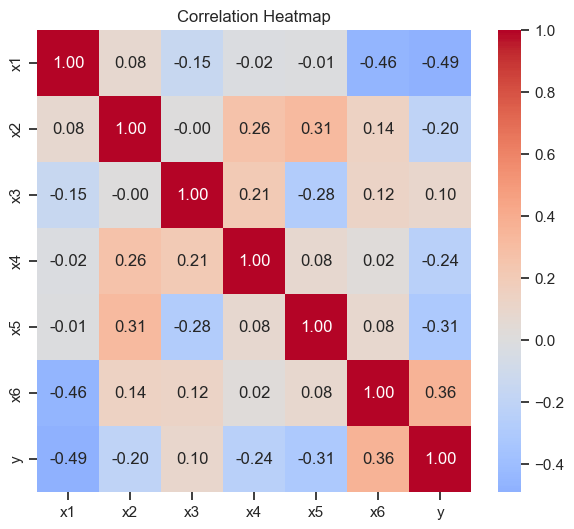

In [12]:
plt.figure(figsize=(7, 6))
sns.heatmap(df.corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


## Bayesian Optimization Setup

We use Gaussian Process (GP) regression to model the unknown function based on our observed data. The GP provides both a mean prediction and uncertainty estimates. The search space is defined as [0, 1] for each of the six input variables.

**Strategy Evolution:**
- **Week 1:** Used UCB with manual override to avoid extreme values. The manually adjusted point scored ≈0.034.
- **Week 2:** UCB suggested a low x1/x2/x4/x5, high x3 point; it scored ≈1.31 (now our #2 result).
- **Week 3:** EI proposal at very low x1/x2/x3 with mid x4/x5 and high-ish x6 scored ≈1.65 (new best). With such a sharp improvement, we keep EI but increase `xi` to 0.05 to encourage exploration away from the newly dominant region and avoid overconfidence.

Since hyperparameter tuning has minimal noise (no human judgment, deterministic evaluation), we omit the WhiteKernel. With 33 points across 6 dimensions, we keep anisotropic Matern(ν=2.5) with bounds 0.2–5.0. The fitted lengthscales are roughly `[1.25, 1.18, 2.52, 0.67, 0.28, 0.48]`, indicating x5 and x6 are the most influential, x4 is moderate, x1/x2 contribute somewhat, and x3 remains the least sensitive feature.




In [13]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.optimize import minimize
np.random.seed(42)
# Per-feature lengthscales with bounds (assuming little noise, no WhiteKernel)
kernel = Matern(
    length_scale=[1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
    length_scale_bounds=(0.2, 5.0),
    nu=2.5
)
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=5)
gp.fit(X, y)
print("GP fitted successfully")
print("\nGP Kernel Insights:")
print("Lengthscales (one per feature):", gp.kernel_.length_scale)
print("Full kernel parameters:", gp.kernel_.get_params())


GP fitted successfully

GP Kernel Insights:
Lengthscales (one per feature): [1.24980639 1.17778965 2.51639393 0.6651568  0.27838066 0.48305887]
Full kernel parameters: {'length_scale': array([1.24980639, 1.17778965, 2.51639393, 0.6651568 , 0.27838066,
       0.48305887]), 'length_scale_bounds': (0.2, 5.0), 'nu': 2.5}


## Finding the Next Point to Evaluate (Week 4)

After the sharp Week 3 gain, we switch EI back toward **exploitation** with a smaller `xi = 0.01`, biasing suggestions closer to the known high ridge (very low x1/x2/x3, mid x4/x5, high-ish x6) rather than far-flung exploration.


In [ ]:
from scipy.stats import norm

xi = 0.01  # Shift back toward exploitation near the known good ridge
# Expected Improvement acquisition function
def expected_improvement(x, gp, y_best, xi=xi):
    """
    Expected Improvement acquisition function.
    
    Args:
        x: Point to evaluate
        gp: Fitted Gaussian Process
        y_best: Best observed value so far
        xi: Exploration-exploitation trade-off parameter (larger values encourage exploration)
    
    Returns:
        Negative EI (for minimization)
    """
    x = x.reshape(1, -1)
    mu, sigma = gp.predict(x, return_std=True)
    
    # Add small epsilon to avoid division by zero
    sigma = sigma + 1e-9
    
    # Calculate improvement
    improvement = mu - y_best - xi
    Z = improvement / sigma
    
    # Expected Improvement formula
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    
    return -ei[0]  # Return negative for minimization

# Get current best
y_best = y.max()
best_idx = y.argmax()
print(f"Current best score: {y_best:.4f}")
print(f"Current best point: {X[best_idx]}")

# Optimize acquisition function with multiple random restarts
bounds = [(0, 1)] * 6
n_restarts = 30
best_acquisition = np.inf
best_candidate = None

np.random.seed(42)
for i in range(n_restarts):
    x0 = np.random.uniform(0, 1, 6)
    result = minimize(
        lambda x: expected_improvement(x, gp, y_best, xi=xi),
        x0=x0,
        bounds=bounds,
        method='L-BFGS-B'
    )
    
    if result.fun < best_acquisition:
        best_acquisition = result.fun
        best_candidate = result.x

next_point = best_candidate
mu_pred, sigma_pred = gp.predict(next_point.reshape(1, -1), return_std=True)

print(f"\n{'='*60}")
print("BAYESIAN OPTIMIZATION RECOMMENDATION (Expected Improvement)")
print(f"{'='*60}")
print(f"\nNext point to evaluate:")
print(f"  x1={next_point[0]:.4f}, x2={next_point[1]:.4f}, x3={next_point[2]:.4f}")
print(f"  x4={next_point[3]:.4f}, x5={next_point[4]:.4f}, x6={next_point[5]:.4f}")
print(f"\nPredicted output: {mu_pred[0]:.4f} ± {sigma_pred[0]:.4f}")
print(f"Expected Improvement: {-best_acquisition:.6f}")


Current best score: 1.6455
Current best point: [0.     0.0741 0.     0.1973 0.3792 0.7271]

BAYESIAN OPTIMIZATION RECOMMENDATION (Expected Improvement)

Next point to evaluate:
  x1=0.0000, x2=0.0804, x3=0.0000
  x4=0.0543, x5=0.3607, x6=0.7677

Predicted output: 1.6254 ± 0.1128
Expected Improvement: 0.031520


<!-- Distance analysis removed per latest guidance. -->


## Analysis and Recommendation

- **New evidence:** The Week 3 EI run `(0.0, 0.0741, 0.0, 0.1973, 0.3792, 0.7271)` delivered **≈1.65**, our new global best. It reinforces a ridge at very low x1/x2/x3 with mid x4/x5 and high-ish x6.
- **Model interpretation:** The refit GP (Matern ν=2.5, bounds 0.2–5.0) yields lengthscales ≈ `[1.25, 1.18, 2.52, 0.67, 0.28, 0.48]`: x5 and x6 remain most influential, x4 is moderate, x1/x2 contribute somewhat, and x3 is the least sensitive dimension. The sharp gain implies local structure, so we raised `xi` to 0.05 to encourage exploration beyond the new optimum.
- **Next suggestion (EI, xi=0.01):** Rerun the notebook to refresh; with lower `xi`, EI will lean back toward the ridge (very low x1/x2/x3, mid x4/x5, high-ish x6) and should propose a higher-mean candidate than the exploratory 0.49 point.
- **Rationale:** With a strong peak now identified, pure exploitation should keep us near `(0, ~0.07, 0, ~0.2, ~0.38, ~0.73)`. The smaller `xi` steers the search toward that region to confirm and refine the optimum instead of wandering far afield.
- **On dropping dimensions (x1/x3):** Still premature. Lengthscales show x1/x2 contribute (≈1.25/1.18) and x3, while less sensitive, was part of the strong Week 2 result (x3=0.95). Pruning them could erase useful structure; revisit after more evidence or formal ARD relevance checks.


